In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df=pd.read_csv('UpdatedResumeDataSet.csv')

In [3]:
df.shape

(962, 2)

In [5]:
df['Category']

0      Data Science
1      Data Science
2      Data Science
3      Data Science
4      Data Science
           ...     
957         Testing
958         Testing
959         Testing
960         Testing
961         Testing
Name: Category, Length: 962, dtype: str

In [6]:
df['Category'].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Data Science                 40
Mechanical Engineer          40
Sales                        40
Operations Manager           40
ETL Developer                40
Blockchain                   40
Arts                         36
Database                     33
Health and fitness           30
Electrical Engineering       30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

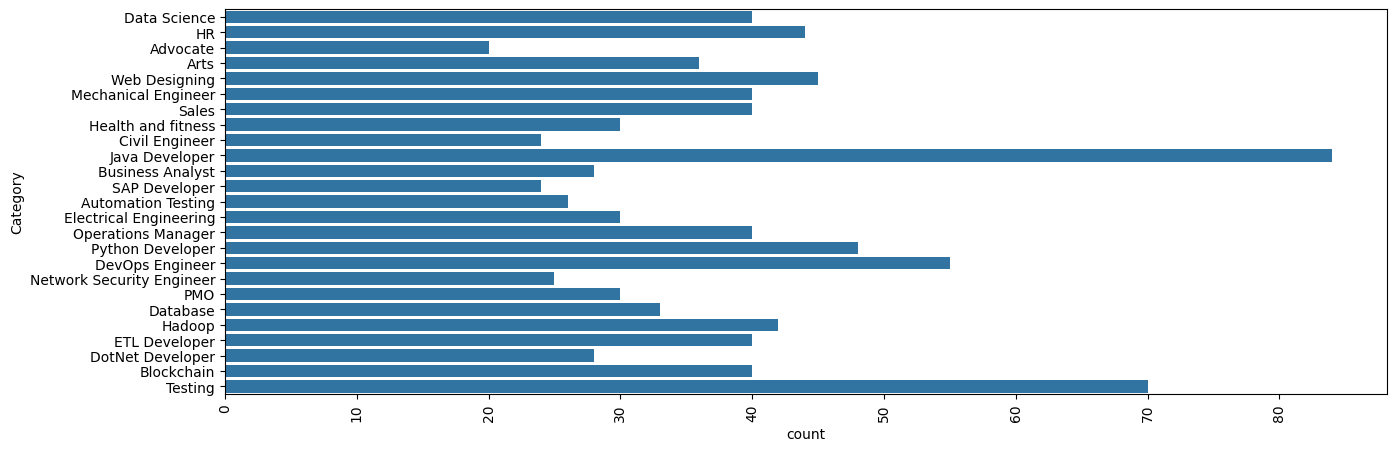

In [10]:
plt.figure(figsize=(15,5))
sns.countplot(df['Category'])
plt.xticks(rotation=90)
plt.show()

In [11]:
df['Category'][0]

'Data Science'

In [12]:
df['Category'][90]

'Advocate'

In [13]:
df['Resume'][90]

'Skills: Natural Languages: Proficient in English, Hindi and Marathi. Computer skills: Proficient with MS-Office, Internet operation.Education Details \r\nJanuary 2015 to January 2018 LLB Law Mumbai, Maharashtra Mumbai university\r\nJanuary 2015 B.M.M  Mumbai, Maharashtra S.K.Somaiya College, Mumbai University\r\n H.S.C   Asmita Girls junior College, Maharashtra Board\r\n S.S.C Vidya Bhawan  Maharashtra Board\r\nAdvocate \r\n\r\nLlb student and Journalist\r\nSkill Details \r\nCompany Details \r\ncompany - Criminal lawyer (law firm)\r\ndescription - '

In [16]:
#cleaning the data
from bs4 import BeautifulSoup
import re
import string

def preprocess(txt):
    txt = str(txt).lower().strip()
    txt = txt.replace("\n"," ").replace("\r"," ").replace("\t"," ")
    txt = txt.replace("’","'").replace("‘","'").replace("“",'"').replace("”",'"')
    txt = re.sub(r'https?\S+\s|www\.\S+\s', '', txt)
    txt = re.sub(r'\S+@\S+\s', '', txt)
    txt = re.sub(r'\S+#\S+\s', '', txt)
    txt = re.sub(r'[^\x00-\x7f]', '', txt)
    
    txt = txt.replace("%"," percent ").replace("$"," dollar ").replace("₹"," rupee ").replace("€"," euro ").replace("£"," pound ").replace("¥"," yen ").replace("₩"," won ").replace("₽"," ruble ").replace("₺"," lira ").replace("₴"," hryvnia ").replace("₦"," naira ").replace("₵"," cedi ").replace("₸"," tenge ").replace("₼"," manat ").replace("₽"," ruble ").replace("₾"," lari ").replace("₿"," bitcoin ")
    txt=re.sub('[%s]' % re.escape(string.punctuation), ' ', txt)
    txt = txt.replace('[math]','').replace('[/math]','')
    txt = txt.replace('000,000,000','b ').replace('000,000','m').replace('000','k')
    txt = re.sub(r'([0-9]+)000000000',' \1b ',txt)
    txt = re.sub(r'([0-9]+)000000',' \1m ',txt)
    txt = re.sub(r'([0-9]+)000',' \1k ',txt)
    
    CONTRACTIONS = {
    # AM
    "ain't":        "am not",
    "i'm":          "i am",

    # ARE
    "aren't":       "are not",
    "you're":       "you are",
    "we're":        "we are",
    "they're":      "they are",
    "who're":       "who are",
    "what're":      "what are",
    "there're":     "there are",

    # IS / HAS
    "isn't":        "is not",
    "he's":         "he is",
    "she's":        "she is",
    "it's":         "it is",
    "that's":       "that is",
    "what's":       "what is",
    "who's":        "who is",
    "where's":      "where is",
    "when's":       "when is",
    "why's":        "why is",
    "how's":        "how is",
    "here's":       "here is",
    "there's":      "there is",
    "this's":       "this is",

    # WAS / WERE
    "wasn't":       "was not",
    "weren't":      "were not",

    # HAVE
    "haven't":      "have not",
    "i've":         "i have",
    "you've":       "you have",
    "we've":        "we have",
    "they've":      "they have",
    "could've":     "could have",
    "should've":    "should have",
    "would've":     "would have",
    "might've":     "might have",
    "must've":      "must have",
    "who've":       "who have",

    # HAD / WOULD
    "hadn't":       "had not",
    "i'd":          "i would",
    "you'd":        "you would",
    "he'd":         "he would",
    "she'd":        "she would",
    "we'd":         "we would",
    "they'd":       "they would",
    "who'd":        "who would",
    "what'd":       "what did",
    "it'd":         "it would",

    # HAS
    "hasn't":       "has not",

    # WILL
    "won't":        "will not",
    "i'll":         "i will",
    "you'll":       "you will",
    "he'll":        "he will",
    "she'll":       "she will",
    "we'll":        "we will",
    "they'll":      "they will",
    "who'll":       "who will",
    "that'll":      "that will",
    "it'll":        "it will",

    # DO / DOES / DID
    "don't":        "do not",
    "doesn't":      "does not",
    "didn't":       "did not",

    # COULD / SHOULD / WOULD / MIGHT / MUST
    "couldn't":     "could not",
    "shouldn't":    "should not",
    "wouldn't":     "would not",
    "mightn't":     "might not",
    "mustn't":      "must not",
    "couldn't've":  "could not have",
    "shouldn't've": "should not have",
    "wouldn't've":  "would not have",

    # CAN
    "can't":        "cannot",
    "can't've":     "cannot have",

    # NEED / DARE
    "needn't":      "need not",
    "needn't've":   "need not have",
    "daren't":      "dare not",

    # MISC
    "'cause":       "because",
    "let's":        "let us",
    "ma'am":        "madam",
    "o'clock":      "of the clock",
    "o'er":         "over",
    "ne'er":        "never",
    "e'er":         "ever",
    "y'all":        "you all",
    "y'all'd":      "you all would",
    "y'all're":     "you all are",
    "y'all've":     "you all have",
    "not've":       "not have",
    "how'd":        "how did",
    "how'd'y":      "how do you",
    "how'll":       "how will",
    "i'd've":       "i would have",
    "it'd've":      "it would have",
    "she'd've":     "she would have",
    "he'd've":      "he would have",
    "we'd've":      "we would have",
    "they'd've":    "they would have",
    "when'd":       "when did",
    "where'd":      "where did",
    "why'd":        "why did",
    "who'd've":     "who would have",
    "that'd":       "that would",
    "that'd've":    "that would have",
    "there'd":      "there would",
    "there'd've":   "there would have",
    "here'd":       "here would",
    "how's":        "how is",
    "i'm":          "i am",
    "you've":       "you have",
    "we've":        "we have",
    "they've":      "they have",
    "who've":       "who have",
    "would've":     "would have",
    "should've":    "should have",
    "could've":     "could have",
    "must've":      "must have",    
    }
    
    txt_dectracted = []
    
    for word in txt.split():
        if word in CONTRACTIONS:
            txt_dectracted.append(CONTRACTIONS[word])
        else:
            txt_dectracted.append(word)
            
    txt = " ".join(txt_dectracted)
    txt = txt.replace("'ve"," have").replace("'re"," are").replace("'ll"," will").replace("'d"," would").replace("'s"," is").replace("n't"," not")
    
    txt = BeautifulSoup(txt, "html.parser")
    txt = txt.get_text()
    
    pattern = re.compile(r'\W')
    txt = re.sub(pattern, ' ', txt).strip()
    
    return txt

In [19]:
df['Resume'] = df['Resume'].apply(preprocess)
df['Resume'][0]

'skills programming languages python pandas numpy scipy scikit learn matplotlib sql java javascript jquery machine learning regression svm nave bayes knn random forest decision trees boosting techniques cluster analysis word embedding sentiment analysis natural language processing dimensionality reduction topic modelling lda nmf pca neural nets database visualizations mysql sqlserver cassandra hbase elasticsearch d3 js dc js plotly kibana matplotlib ggplot tableau others regular expression html css angular 6 logstash kafka python flask git docker computer vision open cv and understanding of deep learning education details data science assurance associate data science assurance associate ernst young llp skill details javascript exprience 24 months jquery exprience 24 months python exprience 24 monthscompany details company ernst young llp description fraud investigations and dispute services assurance technology assisted review tar technology assisted review assists in accelerating the 

In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [21]:
le.fit(df['Category'])
df['Category']= le.transform(df['Category'])
df['Category']

0       6
1       6
2       6
3       6
4       6
       ..
957    23
958    23
959    23
960    23
961    23
Name: Category, Length: 962, dtype: int64

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=3000,stop_words='english')
tfidf.fit(df['Resume'])
resume_tfidf = tfidf.transform(df['Resume'])
print(resume_tfidf.shape)
resume_tfidf

(962, 3000)


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 137252 stored elements and shape (962, 3000)>

In [27]:
features = tfidf.get_feature_names_out()
tfidf_df = pd.DataFrame(resume_tfidf.toarray(), columns=features)
final_df = pd.concat([df[['Category']].reset_index(drop=True), tfidf_df], axis=1)
final_df.head()

,Category,01,02,03,05,07,08,10,10g,10magicalfingers,...,year,years,yes,york,young,yrs,zaggle,zensar,zhypility,zone
0,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.016265,0.0,0.0,0.0,0.092011,0.0,0.0,0.0,0.0,0.0
1,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.300292,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.338257,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
3,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.062278,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
4,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.590242,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(resume_tfidf,df['Category'],test_size=0.2,random_state=42)

In [29]:
X_train.shape

(769, 3000)

In [30]:
X_test.shape

(193, 3000)

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.multiclass import OneVsOneClassifier

clf= OneVsOneClassifier(KNeighborsClassifier())
clf.fit(X_train, y_train)
ypred=clf.predict(X_test)
print(classification_report(y_test,ypred))
print(confusion_matrix(y_test,ypred))
print(accuracy_score(y_test,ypred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         9
           6       0.75      0.60      0.67         5
           7       1.00      0.88      0.93         8
           8       1.00      0.93      0.96        14
           9       1.00      1.00      1.00         5
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00         6
          12       1.00      1.00      1.00        12
          13       1.00      1.00      1.00         4
          14       1.00      1.00      1.00         7
          15       1.00      1.00      1.00        15
          16       1.00      1.00      1.00         8
          17       1.00    

In [ ]:
# Function to predict the category of a resume
def pred(input_resume):
    # Preprocess the input text using your preprocess function (not cleanResume)
    cleaned_text = preprocess(input_resume)  # CHANGED: cleanResume → preprocess

    # Vectorize the cleaned text using the same TF-IDF vectorizer used during training
    vectorized_text = tfidf.transform([cleaned_text])
    
    # Convert sparse matrix to dense
    vectorized_text = vectorized_text.toarray()

    # Prediction - use your trained KNN model (not svc_model)
    predicted_category = clf.predict(vectorized_text)  # CHANGED: svc_model → clf

    # get name of predicted category
    predicted_category_name = le.inverse_transform(predicted_category)

    return predicted_category_name[0]  # Return the category name


In [37]:
myresume = """I am a data scientist specializing in machine
learning, deep learning, and computer vision. With
a strong background in mathematics, statistics,
and programming, I am passionate about
uncovering hidden patterns and insights in data.
I have extensive experience in developing
predictive models, implementing deep learning
algorithms, and designing computer vision
systems. My technical skills include proficiency in
Python, Sklearn, TensorFlow, and PyTorch.
What sets me apart is my ability to effectively
communicate complex concepts to diverse
audiences. I excel in translating technical insights
into actionable recommendations that drive
informed decision-making.
If you're looking for a dedicated and versatile data
scientist to collaborate on impactful projects, I am
eager to contribute my expertise. Let's harness the
power of data together to unlock new possibilities
and shape a better future.
Contact & Sources
Email: 611noorsaeed@gmail.com
Phone: 03442826192
Github: https://github.com/611noorsaeed
Linkdin: https://www.linkedin.com/in/noor-saeed654a23263/
Blogs: https://medium.com/@611noorsaeed
Youtube: Artificial Intelligence
ABOUT ME
WORK EXPERIENCE
SKILLES
NOOR SAEED
LANGUAGES
English
Urdu
Hindi
I am a versatile data scientist with expertise in a wide
range of projects, including machine learning,
recommendation systems, deep learning, and computer
vision. Throughout my career, I have successfully
developed and deployed various machine learning models
to solve complex problems and drive data-driven
decision-making
Machine Learnine
Deep Learning
Computer Vision
Recommendation Systems
Data Visualization
Programming Languages (Python, SQL)
Data Preprocessing and Feature Engineering
Model Evaluation and Deployment
Statistical Analysis
Communication and Collaboration
"""

pred(myresume)

'Data Science'

In [39]:
myresume = """
Jane Smith is a certified personal trainer with over 5 years of experience in helping individuals achieve their fitness goals. Specializing in weight loss, strength training, and sports conditioning, Jane has developed personalized workout routines for clients of all ages and fitness levels. She has extensive knowledge in nutrition and exercise science, and uses this to create holistic health and fitness programs that are tailored to individual needs.

Jane holds a degree in Exercise Science and is a certified trainer through the National Academy of Sports Medicine (NASM). She has worked with athletes, seniors, and individuals with chronic health conditions, helping them improve their physical well-being and overall quality of life.

Her expertise includes:
- Weight Loss and Body Composition
- Strength Training and Resistance Exercises
- Cardio Conditioning
- Nutrition Coaching and Meal Planning
- Injury Prevention and Rehabilitation
- Functional Movement and Flexibility Training
- Group Fitness Classes

Certifications:
- Certified Personal Trainer, NASM
- CPR and First Aid Certified
- Yoga Instructor (200-Hour Certification)

Education:
BSc in Exercise Science, ABC University, 2014-2018

Work Experience:
- Personal Trainer at XYZ Fitness Gym (2018-Present)
- Fitness Coach at Wellness Center (2016-2018)

Languages:
- English (Fluent)
- Spanish (Conversational)
"""
# Now, test the model with the Health and Fitness-focused resume
pred(myresume)

'Health and fitness'

In [40]:
import pickle
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))
pickle.dump(clf, open('knn_model.pkl', 'wb'))
pickle.dump(le, open('label_encoder.pkl', 'wb'))

In [41]:
# BLOCK 1: 3D Distribution of Resume Categories
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd

# Reduce TF-IDF features to 3 dimensions using PCA
pca = PCA(n_components=3)
resume_pca = pca.fit_transform(resume_tfidf.toarray())

# Create a DataFrame for 3D visualization
pca_df = pd.DataFrame({
    'PC1': resume_pca[:, 0],
    'PC2': resume_pca[:, 1],
    'PC3': resume_pca[:, 2],
    'Category': le.inverse_transform(df['Category'])
})

# Create interactive 3D scatter plot
fig = px.scatter_3d(
    pca_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Category',
    title='3D Distribution of Resume Categories (PCA-Reduced TF-IDF Features)',
    labels={
        'PC1': f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)',
        'PC2': f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)',
        'PC3': f'Principal Component 3 ({pca.explained_variance_ratio_[2]:.2%} variance)'
    },
    hover_data={
        'PC1': ':.3f',
        'PC2': ':.3f',
        'PC3': ':.3f'
    },
    opacity=0.7,
    size_max=8
)

# Update layout for better visualization
fig.update_traces(
    marker=dict(size=5),
    selector=dict(mode='markers')
)

fig.update_layout(
    scene=dict(
        xaxis_title='Principal Component 1',
        yaxis_title='Principal Component 2',
        zaxis_title='Principal Component 3',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        )
    ),
    width=1000,
    height=700,
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor="rgba(255, 255, 255, 0.8)"
    )
)

fig.show()

# Print explained variance
print("="*60)
print("PCA Explained Variance Ratio:")
print("="*60)
for i, var in enumerate(pca.explained_variance_ratio_, 1):
    print(f"PC{i}: {var:.2%}")
print(f"\nTotal variance explained by first 3 components: {pca.explained_variance_ratio_.sum():.2%}")

PCA Explained Variance Ratio:
PC1: 3.58%
PC2: 2.93%
PC3: 2.43%

Total variance explained by first 3 components: 8.94%


In [42]:
# BLOCK 2: 3D Test Results Visualization (Actual vs Predicted)
from sklearn.decomposition import PCA
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd

# Get test predictions
y_pred = clf.predict(X_test)
y_test_array = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

# Reduce test data to 3 dimensions
pca_test = PCA(n_components=3)
X_test_dense = X_test.toarray() if hasattr(X_test, 'toarray') else X_test
test_pca = pca_test.fit_transform(X_test_dense)

# Create DataFrame with test results
test_results_df = pd.DataFrame({
    'PC1': test_pca[:, 0],
    'PC2': test_pca[:, 1],
    'PC3': test_pca[:, 2],
    'Actual_Category': le.inverse_transform(y_test_array),
    'Predicted_Category': le.inverse_transform(y_pred),
    'Correct': y_test_array == y_pred
})

# Add column for color coding (green = correct, red = incorrect)
test_results_df['Status'] = test_results_df['Correct'].map({True: '✓ Correct', False: '✗ Incorrect'})

# Create interactive 3D scatter plot
fig2 = px.scatter_3d(
    test_results_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Actual_Category',
    symbol='Status',
    symbol_map={'✓ Correct': 'circle', '✗ Incorrect': 'x'},
    title='3D Visualization of Test Results: Actual vs Predicted Categories',
    labels={
        'PC1': 'Principal Component 1',
        'PC2': 'Principal Component 2', 
        'PC3': 'Principal Component 3',
        'Actual_Category': 'Actual Category',
        'Status': 'Prediction Status'
    },
    hover_data={
        'Actual_Category': True,
        'Predicted_Category': True,
        'Status': True,
        'PC1': ':.3f',
        'PC2': ':.3f',
        'PC3': ':.3f'
    },
    opacity=0.8,
    size_max=10
)

# Update marker styles
fig2.update_traces(
    marker=dict(size=6),
    selector=dict(mode='markers')
)

fig2.update_layout(
    scene=dict(
        xaxis_title='Principal Component 1',
        yaxis_title='Principal Component 2',
        zaxis_title='Principal Component 3',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        )
    ),
    width=1000,
    height=700,
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor="rgba(255, 255, 255, 0.8)"
    )
)

fig2.show()

# Print test statistics
print("="*60)
print("TEST RESULTS SUMMARY")
print("="*60)
print(f"Total Test Samples: {len(test_results_df)}")
print(f"Correct Predictions: {test_results_df['Correct'].sum()}")
print(f"Incorrect Predictions: {(~test_results_df['Correct']).sum()}")
print(f"Accuracy: {test_results_df['Correct'].mean():.2%}")
print("\n" + "="*60)
print("MISCLASSIFIED SAMPLES:")
print("="*60)
misclassified = test_results_df[~test_results_df['Correct']]
if len(misclassified) > 0:
    for idx, row in misclassified.iterrows():
        print(f"Sample {idx}: Actual={row['Actual_Category']} → Predicted={row['Predicted_Category']}")
else:
    print("No misclassified samples found!")

# Per-category accuracy
print("\n" + "="*60)
print("PER-CATEGORY ACCURACY:")
print("="*60)
category_accuracy = test_results_df.groupby('Actual_Category').agg(
    Total=('Correct', 'count'),
    Correct=('Correct', 'sum')
)
category_accuracy['Accuracy'] = category_accuracy['Correct'] / category_accuracy['Total']
for category in category_accuracy.index:
    print(f"{category:25s}: {category_accuracy.loc[category, 'Accuracy']:.2%} ({int(category_accuracy.loc[category, 'Correct'])}/{int(category_accuracy.loc[category, 'Total'])})")

TEST RESULTS SUMMARY
Total Test Samples: 193
Correct Predictions: 189
Incorrect Predictions: 4
Accuracy: 97.93%

MISCLASSIFIED SAMPLES:
Sample 25: Actual=Data Science → Predicted=SAP Developer
Sample 36: Actual=Database → Predicted=Data Science
Sample 131: Actual=DevOps Engineer → Predicted=PMO
Sample 189: Actual=Data Science → Predicted=SAP Developer

PER-CATEGORY ACCURACY:
Advocate                 : 100.00% (3/3)
Arts                     : 100.00% (6/6)
Automation Testing       : 100.00% (5/5)
Blockchain               : 100.00% (7/7)
Business Analyst         : 100.00% (4/4)
Civil Engineer           : 100.00% (9/9)
Data Science             : 60.00% (3/5)
Database                 : 87.50% (7/8)
DevOps Engineer          : 92.86% (13/14)
DotNet Developer         : 100.00% (5/5)
ETL Developer            : 100.00% (7/7)
Electrical Engineering   : 100.00% (6/6)
HR                       : 100.00% (12/12)
Hadoop                   : 100.00% (4/4)
Health and fitness       : 100.00% (7/7)
Java D